In [1]:
from pathlib import Path
from pprint import pprint

import pandas as pd

from ORBIT import ProjectManager

# Ensure the correct examples directory is used when running this in docs or in examples
here = Path(".").resolve()
example_dir = here.parents[2] / "examples" if here.stem == "tutorial" else here

In [2]:
example_dir

PosixPath('/Users/rhammond/GitHub_Public/ORBIT/examples')

In [15]:
config = {
    "design_phases": [
        "MonopileDesign",
        "ScourProtectionDesign",
        "ArraySystemDesign",
        "ExportSystemDesign",
        "OffshoreSubstationDesign",
    ],
    "install_phases": {
        "MonopileInstallation": "04/01/2020",
        "TurbineInstallation": "05/01/2020",
        "ArrayCableInstallation": "08/01/2020",
        "OffshoreSubstationInstallation": "08/01/2020",
        "ScourProtectionInstallation": "03/01/2021",
        "ExportCableInstallation": "08/15/2020",
    },
    "turbine": "12MW_generic",
    "project_parameters": {"turbine_capex": 1500},
    "site": {
        "depth": 22.5,
        "distance": 124,
        "distance_to_landfall": 35,
        "mean_windspeed": 9,
    },
    "plant": {
        "layout": "grid",
        "num_turbines": 50,
        "row_spacing": 7,
        "substation_distance": 1,
        "turbine_spacing": 7,
    },
    "array_system_design": {"cables": ["XLPE_630mm_33kV", "XLPE_400mm_33kV"]},
    "export_system_design": {
        "cables": "XLPE_500mm_132kV",
        "percent_added_length": 0.0,
        "landfall": {"interconnection_distance": 3, "trench_length": 2},
    },
    "scour_protection_design": {"cost_per_tonne": 40, "scour_protection_depth": 1},
    "OffshoreSubstationInstallation": {
        "feeder": "example_heavy_feeder",
        "num_feeders": 1,
    },
    "wtiv": "example_wtiv",
    "feeder": "example_heavy_feeder",
    "num_feeders": 2,
    "spi_vessel": "example_scour_protection_vessel",
    "oss_install_vessel": "example_heavy_lift_vessel",
    "array_cable_install_vessel": "example_cable_lay_vessel",
    "export_cable_bury_vessel": "example_cable_lay_vessel",
    "export_cable_install_vessel": "example_cable_lay_vessel",
}

weather_fn = example_dir.parent / "library/weather/"
# weather = pd.read_csv()

project = ProjectManager(config)
project.run()

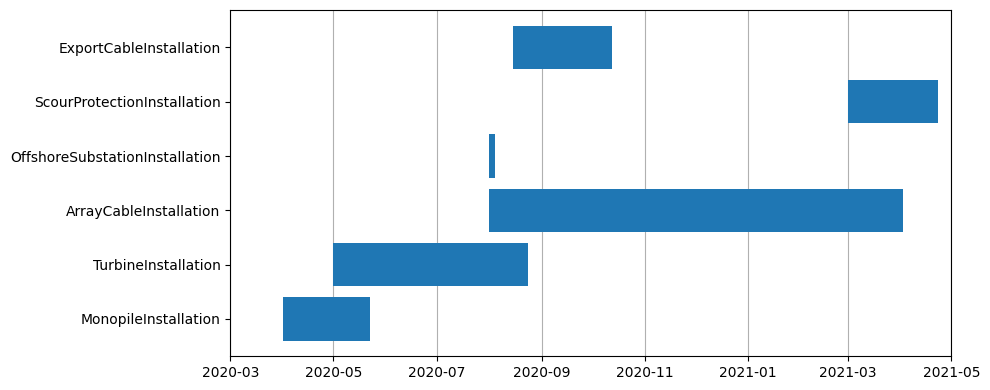

In [32]:
df = pd.DataFrame.from_dict(project.phase_dates).T
df.start = pd.to_datetime(df.start)
df.end = pd.to_datetime(df.end)
df.sort_values("start")

fig = plt.figure(figsize=(10, 4))
ax = fig.add_subplot(111)

ax.barh(y=df.index, width=df.end - df.start, left=df.start);

ax.grid(axis="x")
ax.set_axisbelow(True)
ax.set_xlim(pd.to_datetime("2020-03"), pd.to_datetime("2021-05"))
fig.tight_layout()